# Differential Gene Expression Analysis

Author: Tuan Nguyen

This notebook identifies the significantly differentially expressed genes between the Treatment and Control groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from refactor_function import find_de_genes

### Set Notebook Parameters

Keep the values that vary near the top of the notebook so the next person can rerun it quickly.

In [2]:
expression_file = "simulated_expression_matrix.csv"
alpha = 0.05

**Alternative option**: Keep configurations separately

In [3]:
config_path = "config.yaml"
with open(config_path, "r") as file:
    config = yaml.safe_load(file)

# Set default values
expression_file = config.get("expression_file", "simulated_expression_matrix.csv")
alpha = config.get("alpha", 0.05)

Recommendation: print out the configs chosen

In [4]:
print(f"Using expression file: {expression_file}")
print(f"Using alpha: {alpha}")

Using expression file: simulated_expression_matrix.csv
Using alpha: 0.05


### Run The Analysis and View Results

The notebook wrapper should call the reusable function and keep the workflow readable. Describe what each code chunk does.

Perform statistical testing to identify significant genes.

In [5]:
df = pd.read_csv(expression_file, index_col=0)
significant_de_genes = find_de_genes(df, alpha=alpha)

In [6]:
print(f"Number of significant genes: {len(significant_de_genes)}")
print("Top significant genes:")
print(significant_de_genes.head())


Number of significant genes: 11
Top significant genes:
      gene      pval   Control  Treatment        fc      padj
89  Gene_9  0.000002  5.635662   6.172900  0.537238  0.000169
56  Gene_6  0.000003  5.588058   6.069368  0.481310  0.000172
12  Gene_2  0.000010  5.658850   6.167062  0.508213  0.000331
67  Gene_7  0.000041  5.635703   6.031629  0.395926  0.001036
78  Gene_8  0.000073  5.615413   6.192122  0.576709  0.001456


Quick visualization.

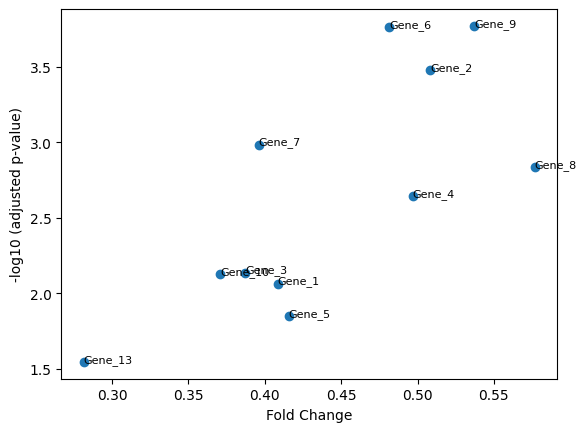

In [7]:
significant_de_genes['log10_padj'] = -np.log10(significant_de_genes['padj'].astype(float))
plt.plot(significant_de_genes["fc"], significant_de_genes["log10_padj"], "o")

for _, row in significant_de_genes.iterrows():
    plt.text(row["fc"], row["log10_padj"], row["gene"], fontsize=8)

plt.xlabel("Fold Change")
plt.ylabel("-log10 (adjusted p-value)")
plt.show()